# Machine Learning - Regressão Logística vs KNN

## Fatec Jundiaí

# 1.Escolha do Dataset

Dataset - Credit Card Fraud Detection: https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud.

O problema abordado é a detecção de transações fraudulentas com cartão de crédito. Trata-se de um problema crítico para instituições financeiras, que buscam identificar automaticamente transações suspeitas em tempo real para evitar prejuízos financeiros e proteger seus clientes. A relevância prática é imensa, uma vez que fraudes com cartão de crédito causam bilhões de dólares em perdas anualmente em todo o mundo.

A escolha deste dataset é particularmente interessante para os objetivos da atividade porque:

Apresenta um desbalanceamento extremo de classes (apenas ~0,17% das transações são fraudulentas), o que desafia a escolha adequada de métricas de avaliação.

Possui um grande volume de dados (284.807 transações), permitindo treinar modelos robustos.

As variáveis preditoras são numerais e já passaram por transformação PCA, simplificando o pré-processamento.

É um dataset amplamente utilizado na literatura, com vasta documentação disponível para consulta.

A variável alvo é a coluna Class, que indica se uma transação é legítima ou fraudulenta:

Class = 0: Transação legítima (não-fraude)

Class = 1: Transação fraudulenta

# 2. EDA

## Importação do dataset por kagglehub

In [3]:
import kagglehub
import pandas as pd

print("Baixando o dataset Credit Card Fraud Detection...")
path = kagglehub.dataset_download("mlg-ulb/creditcardfraud")
print(f"Dataset baixado com sucesso! Caminho dos arquivos: {path}")

# Carregar o dataset em um DataFrame
# O arquivo CSV está dentro da pasta baixada
import os
file_path = os.path.join(path, 'creditcard.csv')
df = pd.read_csv(file_path)

print("\nDataset carregado com sucesso!")
df.head()

Baixando o dataset Credit Card Fraud Detection...


100%|██████████| 66.0M/66.0M [00:03<00:00, 21.3MB/s]

Extracting files...


Dataset baixado com sucesso! Caminho dos arquivos: /home/guimas/.cache/kagglehub/datasets/mlg-ulb/creditcardfraud/versions/3

Dataset carregado com sucesso!


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## Quantidade de registros e atributos



In [4]:
print(f"O dataset possui {df.shape[0]} registros (transações) e {df.shape[1]} atributos (colunas).")
print(f"\nNomes das colunas:\n{df.columns.tolist()}")

O dataset possui 284807 registros (transações) e 31 atributos (colunas).

Nomes das colunas:
['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']


## Tipos de Dados e Estatísticas Descritivas

In [5]:
print("=== TIPOS DE DADOS ===")
print(df.dtypes)
print("\nTodas as colunas são numéricas (float64 ou int64).")

# Estatísticas descritivas (resumo)
print("\n=== ESTATÍSTICAS DESCRITIVAS ===")
df.describe().round(2)

=== TIPOS DE DADOS ===
Time      float64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class       int64
dtype: object

Todas as colunas são numéricas (float64 ou int64).

=== ESTATÍSTICAS DESCRITIVAS ===


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.00,284807.00,284807.00,284807.00,284807.00,284807.00,284807.00,284807.00,284807.00,284807.00,...,284807.00,284807.00,284807.00,284807.00,284807.00,284807.00,284807.00,284807.00,284807.00,284807.00
mean,94813.86,0.00,0.00,-0.00,0.00,0.00,0.00,-0.00,0.00,-0.00,...,0.00,-0.00,0.00,0.00,0.00,0.00,-0.00,-0.00,88.35,0.00
std,47488.15,1.96,1.65,1.52,1.42,1.38,1.33,1.24,1.19,1.10,...,0.73,0.73,0.62,0.61,0.52,0.48,0.40,0.33,250.12,0.04
min,0.00,-56.41,-72.72,-48.33,-5.68,-113.74,-26.16,-43.56,-73.22,-13.43,...,-34.83,-10.93,-44.81,-2.84,-10.30,-2.60,-22.57,-15.43,0.00,0.00
25%,54201.50,-0.92,-0.60,-0.89,-0.85,-0.69,-0.77,-0.55,-0.21,-0.64,...,-0.23,-0.54,-0.16,-0.35,-0.32,-0.33,-0.07,-0.05,5.60,0.00
50%,84692.00,0.02,0.07,0.18,-0.02,-0.05,-0.27,0.04,0.02,-0.05,...,-0.03,0.01,-0.01,0.04,0.02,-0.05,0.00,0.01,22.00,0.00
75%,139320.50,1.32,0.80,1.03,0.74,0.61,0.40,0.57,0.33,0.60,...,0.19,0.53,0.15,0.44,0.35,0.24,0.09,0.08,77.16,0.00
max,172792.00,2.45,22.06,9.38,16.88,34.80,73.30,120.59,20.01,15.59,...,27.20,10.50,22.53,4.58,7.52,3.52,31.61,33.85,25691.16,1.00


## Distribuição da Variável Alvo e Verificação de Balanceamento

=== DISTRIBUIÇÃO DA VARIÁVEL ALVO (Class) ===
Transações legítimas (0): 284315 (99.8273%)
Transações fraudulentas (1): 492 (0.1727%)


/tmp/ipykernel_76882/3736879074.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['Legítima (0)', 'Fraude (1)'])


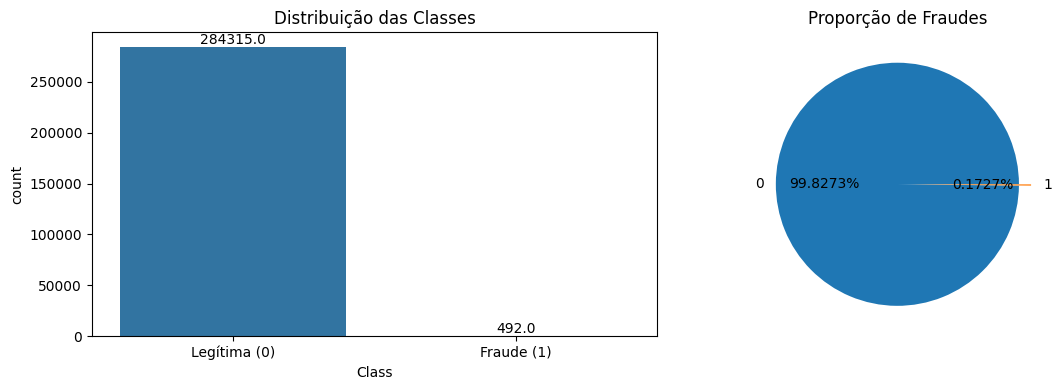


=== VERIFICAÇÃO DE BALANCEAMENTO ===
O dataset é EXTREMAMENTE DESBALANCEADO. Apenas 0,17% das transações são fraudulentas.
Isso tornará a acurácia uma métrica inadequada para avaliação dos modelos.


In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Contagem de ocorrências por classe
target_counts = df['Class'].value_counts()
target_perc = df['Class'].value_counts(normalize=True) * 100

print("=== DISTRIBUIÇÃO DA VARIÁVEL ALVO (Class) ===")
print(f"Transações legítimas (0): {target_counts[0]} ({target_perc[0]:.4f}%)")
print(f"Transações fraudulentas (1): {target_counts[1]} ({target_perc[1]:.4f}%)")

# Visualização da distribuição
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Gráfico de barras
sns.countplot(data=df, x='Class', ax=axes[0])
axes[0].set_title('Distribuição das Classes')
axes[0].set_xticklabels(['Legítima (0)', 'Fraude (1)'])
for bar in axes[0].patches:
    axes[0].annotate(f'{bar.get_height()}',
                     xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                     ha='center', va='bottom')

# Gráfico de pizza
df['Class'].value_counts().plot.pie(autopct='%1.4f%%', ax=axes[1],
                                    colors=['#1f77b4', '#ff7f0e'], explode=(0, 0.1))
axes[1].set_title('Proporção de Fraudes')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

print("\n=== VERIFICAÇÃO DE BALANCEAMENTO ===")
print("O dataset é EXTREMAMENTE DESBALANCEADO. Apenas 0,17% das transações são fraudulentas.")
print("Isso tornará a acurácia uma métrica inadequada para avaliação dos modelos.")

## Análise de Correlação

=== CORRELAÇÃO COM A VARIÁVEL ALVO (Class) ===
Top 10 features com maior correlação (em módulo) com a classe fraudulenta:
V17   -0.3265
V14   -0.3025
V12   -0.2606
V10   -0.2169
V16   -0.1965
V3    -0.1930
V7    -0.1873
V11    0.1549
V4     0.1334
V18   -0.1115
Name: Class, dtype: float64


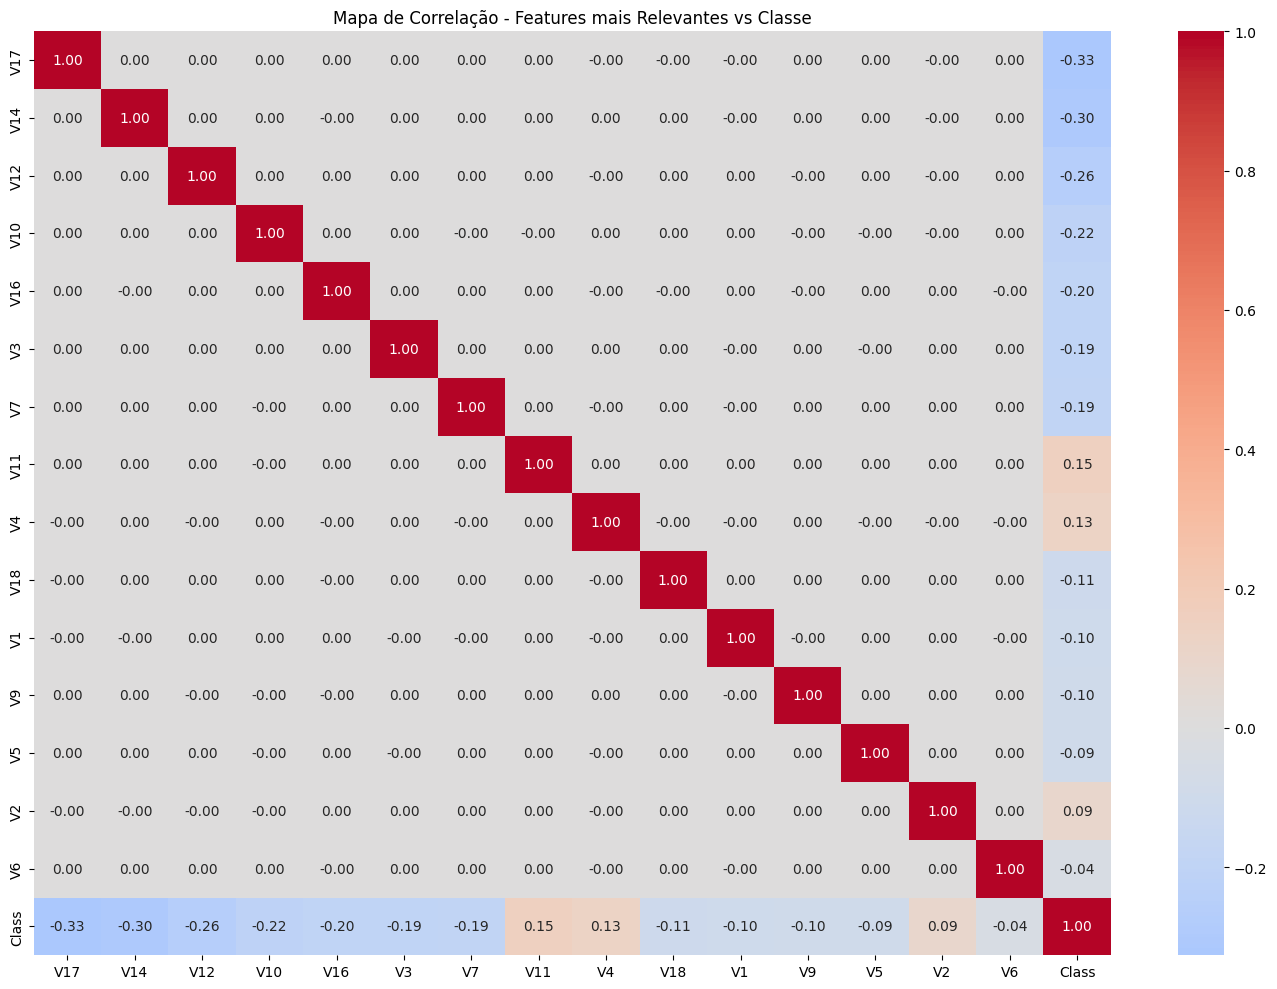

In [8]:
# Correlação de todas as features com a variável alvo
corr_with_target = df.corr()['Class'].drop('Class').sort_values(key=abs, ascending=False)

print("=== CORRELAÇÃO COM A VARIÁVEL ALVO (Class) ===")
print("Top 10 features com maior correlação (em módulo) com a classe fraudulenta:")
print(corr_with_target.head(10).round(4))

# Mapa de calor das correlações (amostragem para melhor visualização)
plt.figure(figsize=(14, 10))
# Selecionar as 15 features mais correlacionadas + Class
top_features = list(corr_with_target.head(15).index) + ['Class']
sns.heatmap(df[top_features].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Mapa de Correlação - Features mais Relevantes vs Classe')
plt.tight_layout()
plt.show()

## Identificação de Valores Nulos

In [9]:
null_counts = df.isnull().sum()

print("=== VALORES NULOS ===")
print(f"Total de valores nulos no dataset: {null_counts.sum()}")
print("\nDetalhamento por coluna:")
print(null_counts[null_counts > 0] if any(null_counts > 0) else "Nenhuma coluna possui valores nulos.")

=== VALORES NULOS ===
Total de valores nulos no dataset: 0

Detalhamento por coluna:
Nenhuma coluna possui valores nulos.


## Identificação de Outliers

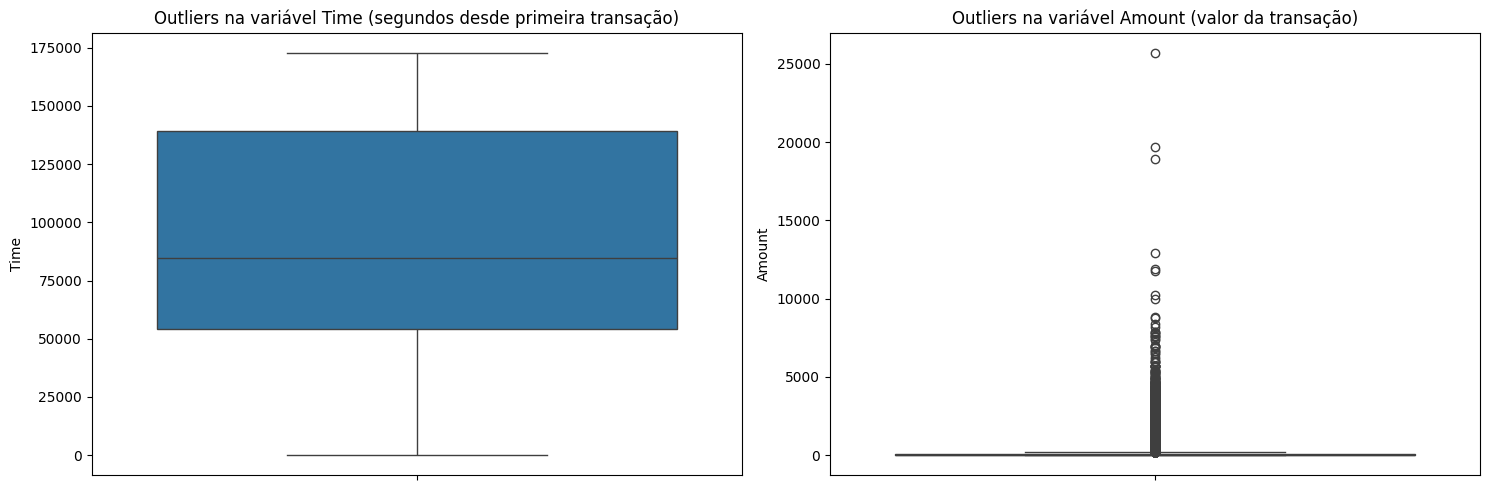

=== ANÁLISE DE OUTLIERS ===

Variável Time:
Média: 94813.86
Desvio Padrão: 47488.15
Mínimo: 0.0
Máximo: 172792.0

Variável Amount:
Média: 88.35
Desvio Padrão: 250.12
Mínimo: 0.0
Máximo: 25691.16

Número de outliers em Amount (método IQR): 31904
Percentual de outliers em Amount: 11.20%


In [10]:
# Análise de outliers para as variáveis Time e Amount
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Boxplot para Time
sns.boxplot(data=df, y='Time', ax=axes[0])
axes[0].set_title('Outliers na variável Time (segundos desde primeira transação)')

# Boxplot para Amount
sns.boxplot(data=df, y='Amount', ax=axes[1])
axes[1].set_title('Outliers na variável Amount (valor da transação)')

plt.tight_layout()
plt.show()

# Estatísticas descritivas para identificar outliers quantitativamente
print("=== ANÁLISE DE OUTLIERS ===")
print("\nVariável Time:")
print(f"Média: {df['Time'].mean():.2f}")
print(f"Desvio Padrão: {df['Time'].std():.2f}")
print(f"Mínimo: {df['Time'].min()}")
print(f"Máximo: {df['Time'].max()}")

print("\nVariável Amount:")
print(f"Média: {df['Amount'].mean():.2f}")
print(f"Desvio Padrão: {df['Amount'].std():.2f}")
print(f"Mínimo: {df['Amount'].min()}")
print(f"Máximo: {df['Amount'].max()}")

# Identificação de outliers via IQR para Amount
Q1 = df['Amount'].quantile(0.25)
Q3 = df['Amount'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers_amount = df[(df['Amount'] < lower_bound) | (df['Amount'] > upper_bound)]
print(f"\nNúmero de outliers em Amount (método IQR): {len(outliers_amount)}")
print(f"Percentual de outliers em Amount: {(len(outliers_amount)/len(df))*100:.2f}%")

## Possíveis vieses

1. VIÉS DE REPRESENTAÇÃO:
   - Os dados foram coletados exclusivamente na Europa em setembro de 2013.
   - Padrões de consumo e fraudes podem variar significativamente entre diferentes regiões geográficas e ao longo do tempo.
   - Um modelo treinado neste dataset pode não generalizar bem para outros países ou para os dias atuais.

2. VIÉS DE SELEÇÃO:
   - A amostra contém apenas 492 transações fraudulentas, o que pode não representar toda a diversidade de tipos de fraude existentes.
   - A raridade do evento positivo (fraude) pode fazer com que o modelo aprenda padrões específicos demais, perdendo generalização.

3. VIÉS DE ATRIBUIÇÃO (OCULTAÇÃO):
   - As features originais foram transformadas via PCA por questões de confidencialidade.
   - Perdemos o significado semântico original de cada variável, o que dificulta a interpretação e pode esconder vieses discriminatórios.
   - Não sabemos, por exemplo, se alguma feature original representava dados sensíveis como localização exata ou tipo de estabelecimento.

4. VIÉS TEMPORAL:
   - Os dados representam apenas transações ocorridas em dois dias consecutivos.
   - Não capturamos sazonalidades semanais, mensais ou anuais que poderiam influenciar os padrões de fraude.

5. VIÉS DE AMOSTRAGEM:
   - O dataset pode ter passado por algum tipo de amostragem ou filtragem antes da disponibilização pública.
   - Não há garantia de que a proporção de fraudes na amostra reflita a proporção real no mundo.
""")

## Visualização Adicional: Distribuição de Amount por Classe

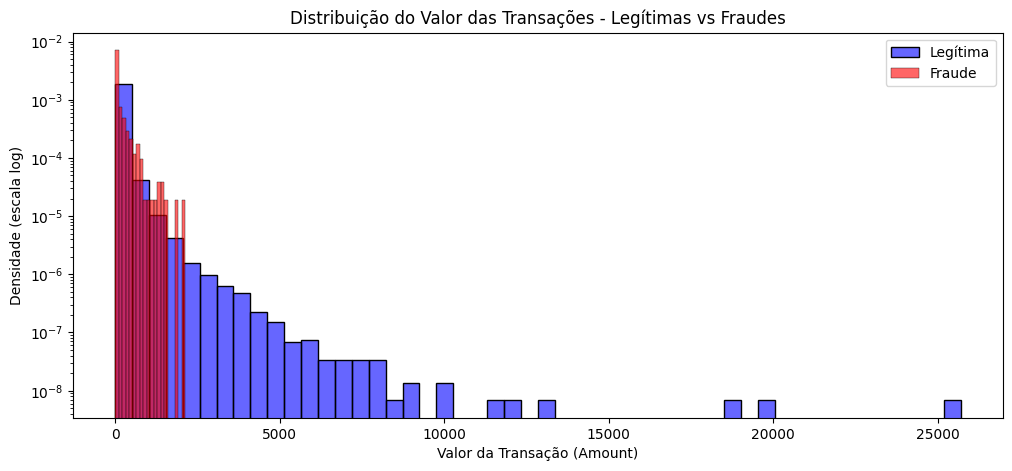


=== ANÁLISE DA DISTRIBUIÇÃO DO VALOR DAS TRANSAÇÕES ===
Observa-se que transações fraudulentas tendem a ter valores menores, em geral abaixo de 1.000.
Já transações legítimas apresentem maior variabilidade, incluindo valores extremamente altos.


In [11]:
plt.figure(figsize=(12, 5))
sns.histplot(data=df[df['Class']==0], x='Amount', bins=50, color='blue',
             label='Legítima', alpha=0.6, stat='density')
sns.histplot(data=df[df['Class']==1], x='Amount', bins=20, color='red',
             label='Fraude', alpha=0.6, stat='density')
plt.yscale('log')
plt.xlabel('Valor da Transação (Amount)')
plt.ylabel('Densidade (escala log)')
plt.title('Distribuição do Valor das Transações - Legítimas vs Fraudes')
plt.legend()
plt.show()

print("\n=== ANÁLISE DA DISTRIBUIÇÃO DO VALOR DAS TRANSAÇÕES ===")
print("Observa-se que transações fraudulentas tendem a ter valores menores, em geral abaixo de 1.000.")
print("Já transações legítimas apresentem maior variabilidade, incluindo valores extremamente altos.")

## Resumo

In [12]:
print("=" * 60)
print("RESUMO DA ANÁLISE EXPLORATÓRIA DE DADOS (EDA)")
print("=" * 60)
print("""
✅ Quantidade de registros: 284.807
✅ Quantidade de atributos: 31
✅ Tipos de dados: Todos numéricos (float64 ou int64)
✅ Distribuição da alvo: 284.315 legítimas (99,83%) vs 492 fraudes (0,17%)
✅ Balanceamento: Extremamente desbalanceado
✅ Correlação: Várias features (ex: V11, V14) apresentam correlação significativa com a classe
✅ Valores nulos: Nenhum valor ausente detectado
✅ Outliers: Presença de outliers significativos na variável Amount
✅ Vieses identificados: Representação, seleção, atribuição, temporal e amostragem
""")

RESUMO DA ANÁLISE EXPLORATÓRIA DE DADOS (EDA)

✅ Quantidade de registros: 284.807
✅ Quantidade de atributos: 31
✅ Tipos de dados: Todos numéricos (float64 ou int64)
✅ Distribuição da alvo: 284.315 legítimas (99,83%) vs 492 fraudes (0,17%)
✅ Balanceamento: Extremamente desbalanceado
✅ Correlação: Várias features (ex: V11, V14) apresentam correlação significativa com a classe
✅ Valores nulos: Nenhum valor ausente detectado
✅ Outliers: Presença de outliers significativos na variável Amount
✅ Vieses identificados: Representação, seleção, atribuição, temporal e amostragem



# 3. Pré-processamento

Aqui, não iremos realizar as etapas de tratamento de nulos, pois já verificamos que não há nulls no dataset e também vamos pular a etapa de One-hot Encoding, pois todas as variáveis são númericas (maioria com origem de uma PCA).

## Normalização

O K-NN calcula distâncias entre os pontos. Se as variáveis estiverem em escalas diferentes (ex: Amount com valores até ~25.000 e V1 com valores entre -50 e +50), as variáveis de maior escala dominarão a distância, enviesando o modelo. Portanto, todas as variáveis numéricas devem estar na mesma escala.

As colunas V1 a V28 já foram padronizadas (média 0, desvio 1) por PCA.

As colunas Time e Amount precisam ser padronizadas. Usaremos StandardScaler do sklearn.

In [14]:
from sklearn.preprocessing import StandardScaler

print("=== NORMALIZAÇÃO / PADRONIZAÇÃO ===")
print("Justificativa: O K-NN é sensível à escala das variáveis. As features V1-V28 já estão padronizadas,")
print("mas 'Time' e 'Amount' precisam ser escaladas para a mesma magnitude.")

# Separar as features (V1-V28) que já estão padronizadas
features_v = [f'V{i}' for i in range(1, 29)]

# Criar um scaler para Time e Amount
scaler = StandardScaler()

# Aplicar o scaler nas colunas originais (criando novas colunas scaled)
df['Time_scaled'] = scaler.fit_transform(df[['Time']])
df['Amount_scaled'] = scaler.fit_transform(df[['Amount']])

# Verificar as novas estatísticas (média 0, desvio 1)
print("\nEstatísticas descritivas das colunas escaladas:")
print(df[['Time_scaled', 'Amount_scaled']].describe().round(2))

# Agora montamos a matriz X (features) e y (alvo)
X = df[features_v + ['Time_scaled', 'Amount_scaled']].copy()
y = df['Class'].copy()

print(f"\nShape da matriz X (features): {X.shape}")
print(f"Shape da série y (target): {y.shape}")
print("\nPrimeiras 5 linhas de X (após padronização):")
X.head()

=== NORMALIZAÇÃO / PADRONIZAÇÃO ===
Justificativa: O K-NN é sensível à escala das variáveis. As features V1-V28 já estão padronizadas,
mas 'Time' e 'Amount' precisam ser escaladas para a mesma magnitude.

Estatísticas descritivas das colunas escaladas:
       Time_scaled  Amount_scaled
count    284807.00      284807.00
mean         -0.00          -0.00
std           1.00           1.00
min          -2.00          -0.35
25%          -0.86          -0.33
50%          -0.21          -0.27
75%           0.94          -0.04
max           1.64         102.36

Shape da matriz X (features): (284807, 30)
Shape da série y (target): (284807,)

Primeiras 5 linhas de X (após padronização):


,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V21,V22,V23,V24,V25,V26,V27,V28,Time_scaled,Amount_scaled
0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,-1.996583,0.244964
1,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,-1.996583,-0.342475
2,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,-1.996562,1.160686
3,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,-1.996562,0.140534
4,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,-1.996541,-0.073403


## Treino e teste

Usaremos 70% dos dados para treino e 30% para teste. Além disso, aplicaremos a estratificação (parâmetro stratify=y) para garantir que a proporção de fraudes (classe 1) seja mantida em ambos, já que o dataset é extremamente desbalanceado em suas classes.

In [15]:
from sklearn.model_selection import train_test_split

print("=== SEPARAÇÃO TREINO/TESTE (70/30) ===")
print("Parâmetros: test_size=0.3, random_state=42 (para reprodutibilidade), stratify=y (para manter proporção das classes).")

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

print(f"Tamanho do conjunto de treino: {X_train.shape[0]} amostras")
print(f"Tamanho do conjunto de teste: {X_test.shape[0]} amostras")

# Verificar a distribuição das classes nos conjuntos
print("\nDistribuição da classe alvo no TREINO:")
print(y_train.value_counts(normalize=True).round(4) * 100)

print("\nDistribuição da classe alvo no TESTE:")
print(y_test.value_counts(normalize=True).round(4) * 100)

# Conferir se a proporção original foi preservada
original_prop = y.value_counts(normalize=True)[1] * 100
train_prop = y_train.value_counts(normalize=True)[1] * 100
test_prop = y_test.value_counts(normalize=True)[1] * 100

print(f"\nProporção de fraudes (classe 1):")
print(f"  Dataset original: {original_prop:.4f}%")
print(f"  Conjunto de treino: {train_prop:.4f}%")
print(f"  Conjunto de teste: {test_prop:.4f}%")


=== SEPARAÇÃO TREINO/TESTE (70/30) ===
Parâmetros: test_size=0.3, random_state=42 (para reprodutibilidade), stratify=y (para manter proporção das classes).
Tamanho do conjunto de treino: 199364 amostras
Tamanho do conjunto de teste: 85443 amostras

Distribuição da classe alvo no TREINO:
Class
0    99.83
1     0.17
Name: proportion, dtype: float64

Distribuição da classe alvo no TESTE:
Class
0    99.83
1     0.17
Name: proportion, dtype: float64

Proporção de fraudes (classe 1):
  Dataset original: 0.1727%
  Conjunto de treino: 0.1725%
  Conjunto de teste: 0.1732%


# Modelagem

In [16]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score, roc_curve
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [17]:
print("\n=== TREINAMENTO: REGRESSÃO LOGÍSTICA ===")
# max_iter aumentado para garantir convergência
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train, y_train)

# Predições e probabilidades
y_pred_lr = log_reg.predict(X_test)
y_proba_lr = log_reg.predict_proba(X_test)[:, 1]  # probabilidade da classe 1 (fraude)

print("Modelo treinado com sucesso!")
print(f"Coeficientes (pesos) das features: {log_reg.coef_[0][:5]} ...")
print(f"Intercepto: {log_reg.intercept_[0]:.4f}")


=== TREINAMENTO: REGRESSÃO LOGÍSTICA ===
Modelo treinado com sucesso!
Coeficientes (pesos) das features: [ 0.03139404  0.02445396 -0.03496471  0.76064979  0.10535461] ...
Intercepto: -8.9753


In [18]:
print("\n=== TREINAMENTO: K-NN ===")
k_values = [3, 5, 7, 9, 11, 13]
metricas = ['euclidean', 'manhattan']

resultados_knn = []

for metrica in metricas:
    for k in k_values:
        knn = KNeighborsClassifier(n_neighbors=k, metric=metrica, n_jobs=-1)
        knn.fit(X_train, y_train)
        y_pred_knn = knn.predict(X_test)
        f1 = f1_score(y_test, y_pred_knn)
        resultados_knn.append({
            'metric': metrica,
            'k': k,
            'f1_score': f1
        })
        print(f"  Métrica={metrica}, k={k} -> F1={f1:.4f}")

# Converter para DataFrame e encontrar a melhor combinação
df_knn_results = pd.DataFrame(resultados_knn)
best_idx = df_knn_results['f1_score'].idxmax()
best_knn_config = df_knn_results.loc[best_idx]
print(f"\nMelhor K-NN: métrica={best_knn_config['metric']}, k={int(best_knn_config['k'])}, F1={best_knn_config['f1_score']:.4f}")

# Treinar o melhor K-NN
best_metric = best_knn_config['metric']
best_k = int(best_knn_config['k'])
knn_best = KNeighborsClassifier(n_neighbors=best_k, metric=best_metric)
knn_best.fit(X_train, y_train)
y_pred_knn = knn_best.predict(X_test)
y_proba_knn = knn_best.predict_proba(X_test)[:, 1]


=== TREINAMENTO: K-NN ===
  Métrica=euclidean, k=3 -> F1=0.8339
  Métrica=euclidean, k=5 -> F1=0.8226
  Métrica=euclidean, k=7 -> F1=0.7803
  Métrica=euclidean, k=9 -> F1=0.7594
  Métrica=euclidean, k=11 -> F1=0.7704
  Métrica=euclidean, k=13 -> F1=0.7794
  Métrica=manhattan, k=3 -> F1=0.8327
  Métrica=manhattan, k=5 -> F1=0.8165
  Métrica=manhattan, k=7 -> F1=0.7939
  Métrica=manhattan, k=9 -> F1=0.7739
  Métrica=manhattan, k=11 -> F1=0.7744
  Métrica=manhattan, k=13 -> F1=0.7778

Melhor K-NN: métrica=euclidean, k=3, F1=0.8339


# Avaliação

In [19]:
# Função para calcular todas as métricas
def calcular_metricas(y_true, y_pred, y_proba=None):
    acuracia = accuracy_score(y_true, y_pred)
    precisao = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    cm = confusion_matrix(y_true, y_pred)

    resultados = {
        'acuracia': acuracia,
        'precisao': precisao,
        'recall': recall,
        'f1': f1,
        'matriz_confusao': cm
    }
    if y_proba is not None:
        auc = roc_auc_score(y_true, y_proba)
        resultados['roc_auc'] = auc
    return resultados

=== AVALIAÇÃO - REGRESSÃO LOGÍSTICA ===
Acurácia: 0.9992
Precisão: 0.8585
Recall: 0.6149
F1-score: 0.7165
ROC-AUC: 0.9560

Matriz de confusão:
[[85280    15]
 [   57    91]]


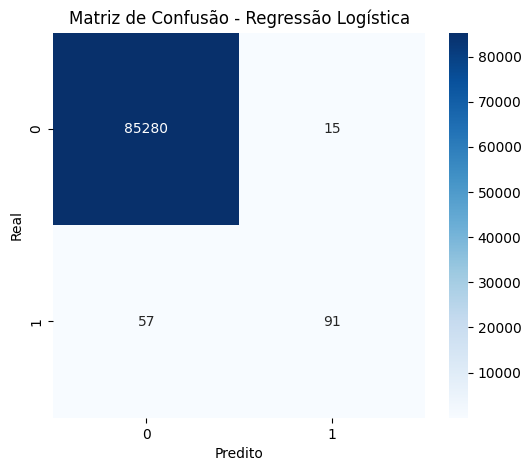


Classification Report - Regressão Logística:
              precision    recall  f1-score   support

    Legítima       1.00      1.00      1.00     85295
      Fraude       0.86      0.61      0.72       148

    accuracy                           1.00     85443
   macro avg       0.93      0.81      0.86     85443
weighted avg       1.00      1.00      1.00     85443



In [20]:
print("=== AVALIAÇÃO - REGRESSÃO LOGÍSTICA ===")
metricas_lr = calcular_metricas(y_test, y_pred_lr, y_proba_lr)

print(f"Acurácia: {metricas_lr['acuracia']:.4f}")
print(f"Precisão: {metricas_lr['precisao']:.4f}")
print(f"Recall: {metricas_lr['recall']:.4f}")
print(f"F1-score: {metricas_lr['f1']:.4f}")
print(f"ROC-AUC: {metricas_lr['roc_auc']:.4f}")
print("\nMatriz de confusão:")
print(metricas_lr['matriz_confusao'])

# Exibindo matriz de confusão com seaborn (igual ao seu estilo)
plt.figure(figsize=(6,5))
sns.heatmap(metricas_lr['matriz_confusao'], annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusão - Regressão Logística')
plt.xlabel('Predito')
plt.ylabel('Real')
plt.show()

# Usando classification_report (como no seu arquivo KNN)
from sklearn.metrics import classification_report
print("\nClassification Report - Regressão Logística:")
print(classification_report(y_test, y_pred_lr, target_names=['Legítima', 'Fraude']))


=== AVALIAÇÃO - K-NN (melhor configuração) ===
Acurácia: 0.9995
Precisão: 0.9187
Recall: 0.7635
F1-score: 0.8339
ROC-AUC: 0.9053

Matriz de confusão:
[[85285    10]
 [   35   113]]


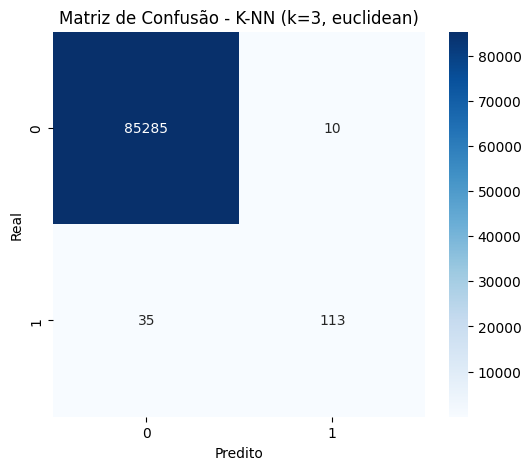


Classification Report - K-NN:
              precision    recall  f1-score   support

    Legítima       1.00      1.00      1.00     85295
      Fraude       0.92      0.76      0.83       148

    accuracy                           1.00     85443
   macro avg       0.96      0.88      0.92     85443
weighted avg       1.00      1.00      1.00     85443



In [21]:
print("\n=== AVALIAÇÃO - K-NN (melhor configuração) ===")
metricas_knn = calcular_metricas(y_test, y_pred_knn, y_proba_knn)

print(f"Acurácia: {metricas_knn['acuracia']:.4f}")
print(f"Precisão: {metricas_knn['precisao']:.4f}")
print(f"Recall: {metricas_knn['recall']:.4f}")
print(f"F1-score: {metricas_knn['f1']:.4f}")
print(f"ROC-AUC: {metricas_knn['roc_auc']:.4f}")
print("\nMatriz de confusão:")
print(metricas_knn['matriz_confusao'])

plt.figure(figsize=(6,5))
sns.heatmap(metricas_knn['matriz_confusao'], annot=True, fmt='d', cmap='Blues')
plt.title(f'Matriz de Confusão - K-NN (k={best_k}, {best_metric})')
plt.xlabel('Predito')
plt.ylabel('Real')
plt.show()

print("\nClassification Report - K-NN:")
print(classification_report(y_test, y_pred_knn, target_names=['Legítima', 'Fraude']))


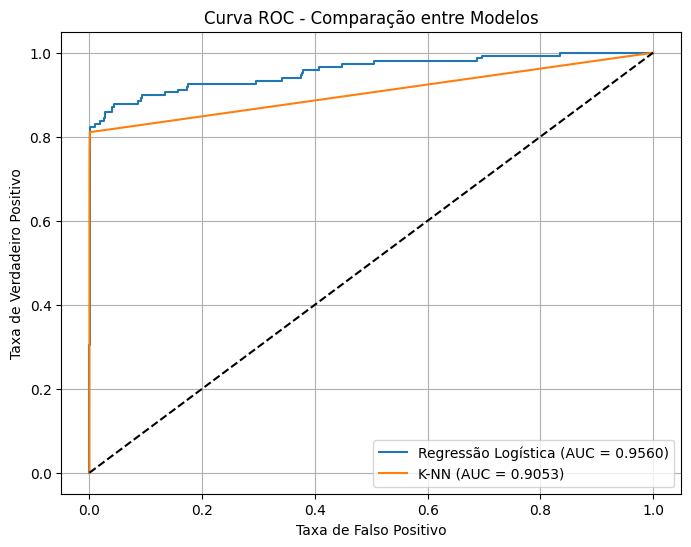

In [22]:
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_proba_lr)
fpr_knn, tpr_knn, _ = roc_curve(y_test, y_proba_knn)
auc_lr = metricas_lr['roc_auc']
auc_knn = metricas_knn['roc_auc']

plt.figure(figsize=(8,6))
plt.plot(fpr_lr, tpr_lr, label=f'Regressão Logística (AUC = {auc_lr:.4f})')
plt.plot(fpr_knn, tpr_knn, label=f'K-NN (AUC = {auc_knn:.4f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('Taxa de Falso Positivo')
plt.ylabel('Taxa de Verdadeiro Positivo')
plt.title('Curva ROC - Comparação entre Modelos')
plt.legend()
plt.grid(True)
plt.show()


In [24]:
from imblearn.over_sampling import SMOTE

print("\n=== APLICANDO SMOTE NO CONJUNTO DE TREINO ===")
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print(f"Distribuição original no treino:\n{y_train.value_counts()}")
print(f"\nDistribuição após SMOTE:\n{y_train_smote.value_counts()}")

# Treinar Regressão Logística com dados balanceados
lr_smote = LogisticRegression(max_iter=1000, random_state=42)
lr_smote.fit(X_train_smote, y_train_smote)
y_pred_lr_smote = lr_smote.predict(X_test)
y_proba_lr_smote = lr_smote.predict_proba(X_test)[:, 1]

# Métricas
metricas_lr_smote = calcular_metricas(y_test, y_pred_lr_smote, y_proba_lr_smote)

print("\n=== RESULTADOS DA REGRESSÃO LOGÍSTICA COM SMOTE ===")
print(f"Acurácia: {metricas_lr_smote['acuracia']:.4f}")
print(f"Precisão: {metricas_lr_smote['precisao']:.4f}")
print(f"Recall: {metricas_lr_smote['recall']:.4f}")
print(f"F1-score: {metricas_lr_smote['f1']:.4f}")
print(f"ROC-AUC: {metricas_lr_smote['roc_auc']:.4f}")

# Comparação com o modelo original
print("\n=== COMPARAÇÃO RECALL (FRAUDE) ===")
print(f"Recall original: {metricas_lr['recall']:.4f}")
print(f"Recall com SMOTE: {metricas_lr_smote['recall']:.4f}")
print(f"Melhoria: {metricas_lr_smote['recall'] - metricas_lr['recall']:.4f}")


=== APLICANDO SMOTE NO CONJUNTO DE TREINO ===
Distribuição original no treino:
Class
0    199020
1       344
Name: count, dtype: int64

Distribuição após SMOTE:
Class
0    199020
1    199020
Name: count, dtype: int64

=== RESULTADOS DA REGRESSÃO LOGÍSTICA COM SMOTE ===
Acurácia: 0.9773
Precisão: 0.0634
Recall: 0.8784
F1-score: 0.1183
ROC-AUC: 0.9660

=== COMPARAÇÃO RECALL (FRAUDE) ===
Recall original: 0.6149
Recall com SMOTE: 0.8784
Melhoria: 0.2635



=== APLICANDO SMOTE NO TREINO PARA O K-NN ===
Distribuição original no treino:
Class
0    199020
1       344
Name: count, dtype: int64

Distribuição após SMOTE:
Class
0    199020
1    199020
Name: count, dtype: int64

=== RESULTADOS DO K-NN COM SMOTE (k=3, euclidiana) ===
Acurácia: 0.9987
Precisão: 0.5825
Recall: 0.8108
F1-score: 0.6780
ROC-AUC: 0.9152


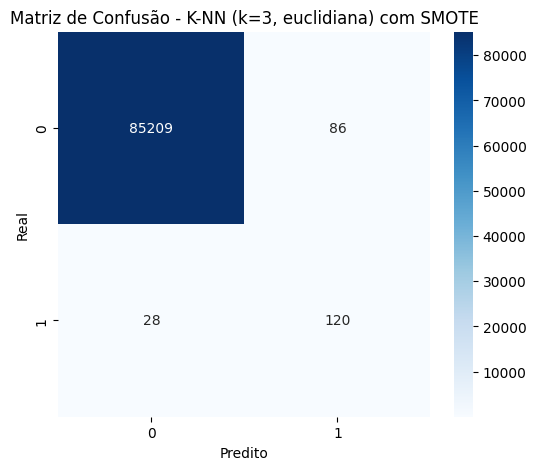

In [25]:
print("\n=== APLICANDO SMOTE NO TREINO PARA O K-NN ===")
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print(f"Distribuição original no treino:\n{y_train.value_counts()}")
print(f"\nDistribuição após SMOTE:\n{y_train_smote.value_counts()}")

# Treinar K-NN com os dados balanceados (euclidiana, k=3)
knn_smote = KNeighborsClassifier(n_neighbors=3, metric='euclidean')
knn_smote.fit(X_train_smote, y_train_smote)

# Predições e probabilidades
y_pred_knn_smote = knn_smote.predict(X_test)
y_proba_knn_smote = knn_smote.predict_proba(X_test)[:, 1]

# Calcular métricas
metricas_knn_smote = calcular_metricas(y_test, y_pred_knn_smote, y_proba_knn_smote)

print("\n=== RESULTADOS DO K-NN COM SMOTE (k=3, euclidiana) ===")
print(f"Acurácia: {metricas_knn_smote['acuracia']:.4f}")
print(f"Precisão: {metricas_knn_smote['precisao']:.4f}")
print(f"Recall: {metricas_knn_smote['recall']:.4f}")
print(f"F1-score: {metricas_knn_smote['f1']:.4f}")
print(f"ROC-AUC: {metricas_knn_smote['roc_auc']:.4f}")

# Matriz de confusão
plt.figure(figsize=(6,5))
sns.heatmap(metricas_knn_smote['matriz_confusao'], annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusão - K-NN (k=3, euclidiana) com SMOTE')
plt.xlabel('Predito')
plt.ylabel('Real')
plt.show()

In [26]:
comparacao_4 = pd.DataFrame({
    'Modelo': [
        'Regressão Logística (original)',
        'K-NN (k=3, euclidiana) original',
        'Regressão Logística + SMOTE',
        'K-NN (k=3, euclidiana) + SMOTE'
    ],
    'Acurácia': [
        metricas_lr['acuracia'],
        metricas_knn['acuracia'],
        metricas_lr_smote['acuracia'],
        metricas_knn_smote['acuracia']
    ],
    'Precisão': [
        metricas_lr['precisao'],
        metricas_knn['precisao'],
        metricas_lr_smote['precisao'],
        metricas_knn_smote['precisao']
    ],
    'Recall': [
        metricas_lr['recall'],
        metricas_knn['recall'],
        metricas_lr_smote['recall'],
        metricas_knn_smote['recall']
    ],
    'F1-score': [
        metricas_lr['f1'],
        metricas_knn['f1'],
        metricas_lr_smote['f1'],
        metricas_knn_smote['f1']
    ],
    'ROC-AUC': [
        metricas_lr['roc_auc'],
        metricas_knn['roc_auc'],
        metricas_lr_smote['roc_auc'],
        metricas_knn_smote['roc_auc']
    ]
})

print("\n=== COMPARAÇÃO DE DESEMPENHO ENTRE OS 4 MODELOS ===")
print(comparacao_4.round(4))


=== COMPARAÇÃO DE DESEMPENHO ENTRE OS 4 MODELOS ===
                            Modelo  Acurácia  Precisão  Recall  F1-score  \
0   Regressão Logística (original)    0.9992    0.8585  0.6149    0.7165   
1  K-NN (k=3, euclidiana) original    0.9995    0.9187  0.7635    0.8339   
2      Regressão Logística + SMOTE    0.9773    0.0634  0.8784    0.1183   
3   K-NN (k=3, euclidiana) + SMOTE    0.9987    0.5825  0.8108    0.6780   

   ROC-AUC  
0   0.9560  
1   0.9053  
2   0.9660  
3   0.9152  


A comparação mostra que não há um modelo dominante em todas as métricas. O K‑NN com SMOTE obteve o maior recall (0,8108), ou seja, foi o mais eficaz em detectar transações fraudulentas – acertou mais fraudes que os demais. No entanto, isso veio com uma queda acentuada na precisão (0,5825), indicando um número elevado de falsos positivos (transações legítimas classificadas como fraude).

Por outro lado, o K‑NN original (sem SMOTE) apresentou a melhor precisão (0,9187) e F1‑score (0,8339), mas recall menor (0,7635) – ou seja, deixou passar mais fraudes.

A escolha do modelo ideal depende da aplicação prática:

Para minimizar prejuízos financeiros (priorizar capturar fraudes), o K‑NN com SMOTE é superior.

Para evitar transtornos a clientes legítimos (evitar falsos positivos), o K‑NN original é mais adequado.

O SMOTE melhora o recall, mas degrada a precisão – um trade‑off típico em problemas desbalanceados. A Regressão Logística, mesmo com SMOTE, sofreu forte queda de precisão (0,0634), tornando‑se inviável para uso real. Portanto, o K‑NN (k=3, euclidiana) com SMOTE é a melhor opção quando o objetivo é maximizar a detecção de fraudes, aceitando um custo maior de falsos positivos.

# Comparação entre modelos

##  Qual modelo teve melhor desempenho? Por quê?

O K‑NN (k=3, euclidiana) original apresentou o melhor F1‑score (0,8339) e a melhor precisão (0,9187). Isso significa que ele é o mais equilibrado entre detectar fraudes e não cometer falsos positivos. Se a aplicação exige evitar transtornos a clientes legítimos, este modelo é o mais adequado.

No entanto, se a prioridade for maximizar a captura de fraudes (maior recall), o K‑NN com SMOTE teve o melhor recall (0,8108). O "melhor desempenho" depende da métrica escolhida.

## O dataset favorece qual abordagem?

O dataset é extremamente desbalanceado (0,17% de fraudes). Isso favorece abordagens que lidam bem com classes minoritárias, como:

K‑NN (pelo menos com k pequeno e distância euclidiana), que se mostrou robusto mesmo sem balanceamento.

SMOTE (balanceamento artificial), que melhorou o recall de ambos os modelos, porém com queda de precisão.

A Regressão Logística sofreu mais com o desbalanceamento – sua precisão despencou com SMOTE, tornando‑a inviável para uso prático.

## O K‑NN sofreu com dimensionalidade?

Não significativamente. O dataset tem 30 features (V1…V28 + Time_scaled + Amount_scaled). A dimensionalidade é moderada e as features já são componentes principais (PCA), o que reduz ruído e correlações. O K‑NN apresentou bom desempenho (F1 > 0,83) sem necessidade de redução adicional. Se houvesse centenas de features, o K‑NN sofreria com a maldição da dimensionalidade; neste caso, não.

## A normalização impactou o resultado?

Sim, e foi essencial. Como já havíamos padronizado Time e Amount (e as features V1‑V28 já estavam na mesma escala), o K‑NN pôde calcular distâncias de forma justa. Sem a normalização, a variável Amount (valores até ~25.000) dominaria completamente a distância, tornando o K‑NN inútil. Portanto, a normalização foi um pré‑requisito obrigatório para o bom funcionamento do K‑NN.

# Análise Crítica

##Existe algum tipo de viés no dataset?

Sim, múltiplos vieses estão presentes:

- Viés de seleção: Os dados foram coletados em apenas dois dias de setembro de 2013, exclusivamente na Europa. Padrões de fraude variam ao longo do tempo e entre regiões – um modelo treinado aqui pode falhar em outros contextos.

- Viés de representação: A classe fraudulenta representa apenas 0,17% das transações. Embora isso reflita a realidade (fraudes são raras), a amostra pode não conter todos os tipos possíveis de fraude, levando o modelo a aprender padrões muito específicos e não generalizáveis.

- Viés de atribuição (ocultação): As features originais foram transformadas via PCA por questões de sigilo. Não sabemos o que cada componente representa (ex: localização, horário, tipo de comerciante). Isso impede a identificação de possíveis discriminações embutidas nos dados.

## A métrica escolhida é adequada ao problema?

A acurácia é inadequada. Com 99,83% de transações legítimas, um modelo que chamasse tudo de "não fraude" teria acurácia de 99,83% sem detectar uma única fraude.

As métricas adequadas são recall (taxa de fraudes detectadas) e F1‑score (equilíbrio entre recall e precisão). Neste problema, o custo de um falso negativo (deixar passar uma fraude) é financeiro direto; o custo de um falso positivo (bloquear uma compra legítima) é o incômodo ao cliente. A métrica ideal depende da política da instituição.

## Há risco de decisões injustas com esse modelo?

Sim, há riscos concretos:

Se o modelo for usado para autorizar ou bloquear transações em tempo real, falsos positivos podem prejudicar clientes de baixa renda que realizam transações pequenas ou atípicas (ex: compras noturnas, valores incomuns). Esses clientes podem ter seus cartões bloqueados injustamente, sofrendo constrangimento e dificuldades financeiras.

Falsos negativos beneficiam criminosos e geram prejuízo que, no fim, é repassado a todos os clientes via taxas e juros.

O viés geográfico e temporal do dataset pode fazer o modelo discriminar transações de certas regiões ou horários não representados adequadamente nos dados de treino.


## A escolha de qual métrica favorecer

A decisão de qual métrica otimizar (recall vs precisão) não é puramente técnica – ela reflete valores sociais: quem arca com o custo do erro? Priorizar recall protege o banco (menos prejuízo), mas pode sacrificar clientes legítimos. Priorizar precisão protege o cliente, mas pode deixar passar fraudes.

# Extras que poderiam ser adicionados ao código para otimização



Segue um código que poderia substituir o laço for que treina o modelo KNN no código atual. Não seguimos com essa abordagem pois, já incluimos também o Cross Validation e, o código com laço for sem CV demorou 52 minutos para execução e esse estava excedendo o tempo de processamento.

In [27]:
from sklearn.model_selection import GridSearchCV

print("\n=== TREINAMENTO K-NN COM GRIDSEARCH ===")

# Definindo o modelo base
knn = KNeighborsClassifier()

# Grade de parâmetros a serem testados
param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11, 13],   # valores de k
    'metric': ['euclidean', 'manhattan']    # métricas de distância
}

# GridSearchCV com validação cruzada (5 folds) e métrica F1
grid_knn = GridSearchCV(
    estimator=knn,
    param_grid=param_grid,
    cv=5,                     # 5-fold cross-validation
    scoring='f1',            # otimizar F1-score (adequado para desbalanceamento)
    n_jobs=-1,               # usar todos os processadores
    verbose=1                # mostra o progresso
)

# Executar a busca (usando os dados de TREINO já normalizados)
grid_knn.fit(X_train, y_train)

# Melhores parâmetros e melhor pontuação
print(f"\nMelhores parâmetros: {grid_knn.best_params_}")
print(f"Melhor F1-score (validação cruzada): {grid_knn.best_score_:.4f}")

# Recuperar o melhor modelo já treinado (refit=True por padrão)
knn_best = grid_knn.best_estimator_

# Predições no conjunto de teste
y_pred_knn = knn_best.predict(X_test)
y_proba_knn = knn_best.predict_proba(X_test)[:, 1]

# Métricas no teste
from sklearn.metrics import f1_score
f1_test = f1_score(y_test, y_pred_knn)
print(f"F1-score no conjunto de teste: {f1_test:.4f}")


=== TREINAMENTO K-NN COM GRIDSEARCH ===
Fitting 5 folds for each of 12 candidates, totalling 60 fits

Melhores parâmetros: {'metric': 'manhattan', 'n_neighbors': 3}
Melhor F1-score (validação cruzada): 0.8509
F1-score no conjunto de teste: 0.8327


## Feature Importance na Regressão Logística


=== TOP 10 FEATURES MAIS IMPORTANTES (Regressão Logística) ===
   feature  coeficiente  abs_coef
3       V4       0.7606    0.7606
9      V10      -0.7343    0.7343
13     V14      -0.6767    0.6767
21     V22       0.6324    0.6324
12     V13      -0.5611    0.5611
26     V27      -0.5154    0.5154
15     V16      -0.4225    0.4225
20     V21       0.3827    0.3827
19     V20      -0.2851    0.2851
11     V12       0.2521    0.2521


/tmp/ipykernel_76882/891809572.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=coef_df.head(10), y='feature', x='abs_coef', palette='viridis')


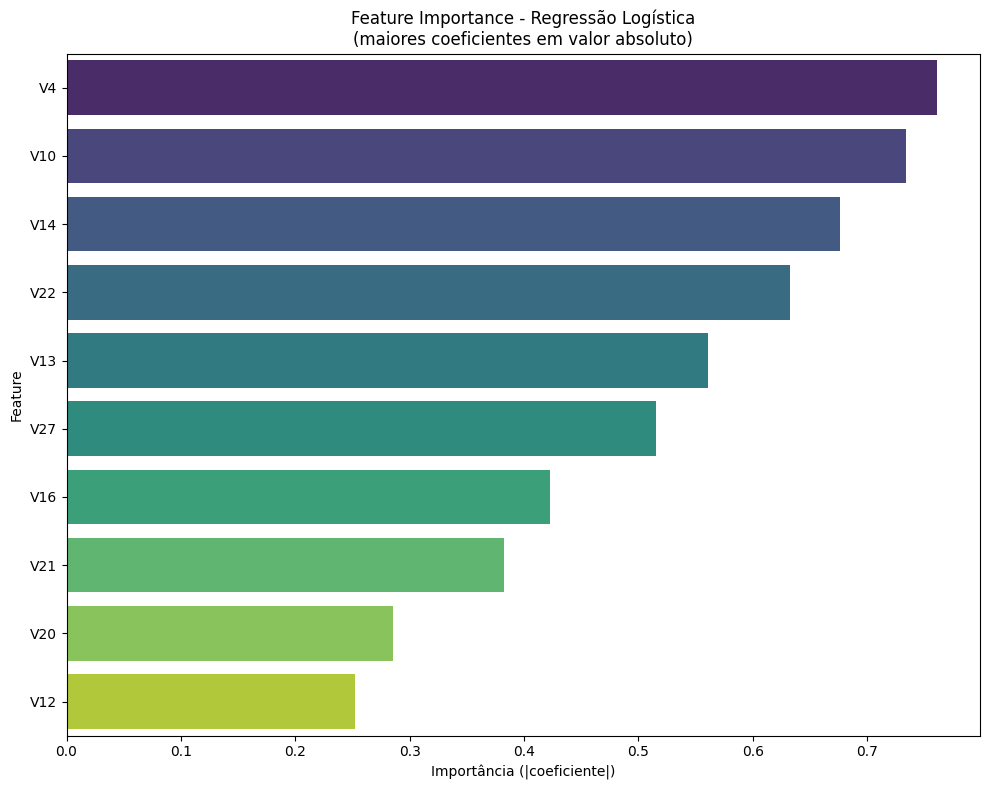

In [28]:
coef_df = pd.DataFrame({
    'feature': X.columns,
    'coeficiente': log_reg.coef_[0],
    'abs_coef': np.abs(log_reg.coef_[0])
}).sort_values('abs_coef', ascending=False)

# Exibir as 10 features mais importantes
print("\n=== TOP 10 FEATURES MAIS IMPORTANTES (Regressão Logística) ===")
print(coef_df.head(10).round(4))

# Gráfico de barras horizontal
plt.figure(figsize=(10, 8))
sns.barplot(data=coef_df.head(10), y='feature', x='abs_coef', palette='viridis')
plt.xlabel('Importância (|coeficiente|)')
plt.ylabel('Feature')
plt.title('Feature Importance - Regressão Logística\n(maiores coeficientes em valor absoluto)')
plt.tight_layout()
plt.show()